# Pollution and Health
## Course Project - CS A1160 Beginner's Python for Engineers
### Team members and Roles:
- Oleksii Lishchuk: Lead Programmer</br>
Programmed the data processing and presenting code
- Teodorus Purnama: Main Report Writer</br>
Wrote and edited the report
- Napat Yisunsri: Presentation manager</br>
Created the slides and organized the presentation

## Overview
This project analyzes the relationship of air pollution levels with health outcomes and urban areas.
### Goal
Investigate the association of pollution levels with:
- Life expectancy
- Cardiovascular disease deaths
- Urban areas
### Data Sources
The following datasets are used due to their quality of reporting, quantity of data, and completeness.
- Main Dataset: WHO Ambient Air Quality Database (Update Jan 2024)</br>
Measurements of annual mean concentrations of nitrogen dioxide (NO2), particulate matter of a diameter equal or smaller than 10 μm (PM10) or equal or smaller than 2.5 μm (PM2.5) (World Health Organization, 2024).
- Additional Dataset: City Health Dashboard</br>
Life expectancy and cardiovascular disease deaths of American cities (Department of Population Health, NYU Langone Health, 2026)

## Project Structure
This notebook follows the structure:
1. Libraries
2. Helper functions
3. Data reading
4. Data cleaning
5. Data merging
6. Statistics calculation
7. Plotting
8. Conclusion
9. Reflection
10. References

## Libraries
This project uses the following libraries to process the datasets.

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

MAIN_FILE="main.xlsx"
ADDITIONAL_FILE="additional.csv"
SHEET_NAME="Update 2024 (V6.1)"

## Helper Functions


In [ ]:
def clean_main_city_name(city_name): #Cleans inconsistent naming
    if pd.isna(city_name):
        return np.nan
    city_name=str(city_name)
    city_name=city_name.split("/")[0]
    city_name=re.sub(r"\s+[A-Z]{2}$","",city_name)
    return city_name.strip()

def annotate_all_points(df,x_col,y_col,label_col): #Annotate city names on plots
    for i,row in df.iterrows():
        plt.annotate(row[label_col],(row[x_col],row[y_col]),fontsize=8)

def station_group(station_type): #Clean inconsistent station types
    if pd.isna(station_type):
        return np.nan
    station_type=str(station_type).lower()
    if "suburban" in station_type:
        return "Suburban"
    if "urban" in station_type:
        return "Urban"
    if "rural" in station_type:
        return "Rural"
    return np.nan

def add_trendline(x,y): #Add a trendline to plots
    x=pd.Series(x).astype(float)
    y=pd.Series(y).astype(float)
    valid=pd.concat([x,y],axis=1).dropna()
    slope,intercept,i,j,k_=stats.linregress(valid.iloc[:,0],valid.iloc[:,1])
    x_line=np.linspace(valid.iloc[:,0].min(),valid.iloc[:,0].max(),200)
    y_line=slope*x_line+intercept
    plt.plot(x_line,y_line,color="red",label="Trendline")

def pearson_r(x,y): #Calculate Pearson correlation
    x=pd.Series(x).astype(float)
    y=pd.Series(y).astype(float)
    valid=pd.concat([x,y],axis=1).dropna()
    return stats.pearsonr(valid.iloc[:,0],valid.iloc[:,1])[0]

def scipy_skew(series): #Returns unbiased estimator
    series=pd.Series(series).dropna()
    return stats.skew(series,bias=False)

def zscore_series(series): #Returns a z score series, for calculating the combined relative index
    series=pd.Series(series).astype(float)
    return pd.Series(stats.zscore(series,nan_policy="omit"),index=series.index)

def summarize_with_ci(df,group_col,value_col,order): #Returns the confidence interval
    summary=df.groupby(group_col)[value_col].agg(["mean","std","count"]).reset_index()
    summary=summary[summary[group_col].isin(order)].copy()
    summary[group_col]=pd.Categorical(summary[group_col],categories=order,ordered=True)
    summary=summary.sort_values(group_col)
    summary["sem"]=summary["std"]/np.sqrt(summary["count"])
    summary["ci95"]=summary.apply(lambda row:stats.t.ppf(0.975,row["count"]-1)*row["sem"],axis=1)
    return summary

## Data Reading

In [ ]:
main_raw=pd.read_excel(MAIN_FILE,sheet_name=SHEET_NAME)
additional_raw=pd.read_csv(ADDITIONAL_FILE)

## Data Cleaning
### Main Dataset
The main dataset includes data from various years and countries. This code filters the dataset to only include data from the United States in the year 2020, to make the data relevant to the additional dataset. The code also changes the name of the city to be consistent with the additional dataset. The columns that are used in the dataset and their contents are as follows:
- pm25_concentration = Annual mean concentration of particulate matter with diameter of 2.5μm or less (µg/m3)
- pm10_concentration = Annual mean concentration of particulate matter with diameter of 10 μm or less (µg/m3)
- no2_concentration = Annual mean concentration of nitrogen dioxide (µg/m3)
- population = Number of inhabitants
- latitude = Latitude of city
- longitude = Longitude of city
- type_of_stations = Type of station (ex: urban, suburban, rural)
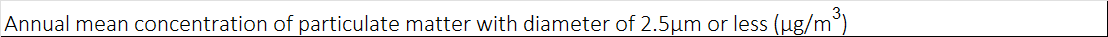

In [ ]:
main_us_2020=main_raw[(main_raw["country_name"]=="United States of America")&(main_raw["year"]==2020)].copy()
main_us_2020["city_clean"]=main_us_2020["city"].apply(clean_main_city_name)

city_air=main_us_2020.groupby("city_clean")[["pm25_concentration","pm10_concentration","no2_concentration","population","latitude","longitude"]].mean().reset_index()
city_air=city_air.rename(columns={"pm25_concentration":"pm25_mean","pm10_concentration":"pm10_mean","no2_concentration":"no2_mean"})

station_info=main_us_2020.groupby("city_clean")["type_of_stations"].first().reset_index()
city_air=city_air.merge(station_info,on="city_clean",how="left")
city_air["station_group"]=city_air["type_of_stations"].apply(station_group)

### Additional Dataset
The additional dataset is cleaned by only taking the "Total" row for each city. This code also makes sure that only non-duplicate cities are used. Finally, it formats the dataset so that it is ready to be merged. The used columns are as follows:
- geo_level = Geographic level of the FIPS code (example: city)
- group_name = Name of demographic represented
- geo_name = Name of the city
- metric_name = Name of metric
- est = Estimated value of the metric

In [ ]:
health_total=additional_raw[(additional_raw["geo_level"]=="city")&(additional_raw["group_name"]=="Total")].copy()

health_total=health_total[["geo_name","metric_name","est"]]
health_total=health_total.drop_duplicates(subset=["geo_name","metric_name"])

health_city=health_total.pivot(index="geo_name",columns="metric_name",values="est").reset_index()
health_city.columns.name=None

health_city=health_city.rename(columns={"geo_name":"city_clean","Cardiovascular Disease Deaths":"cvd_deaths","Life Expectancy - City-Level":"life_expectancy"})

## Data merging
The cleaned main and additional datasets are merged into "analysis_df".

In [ ]:
merged=city_air.merge(health_city,on="city_clean",how="inner")
analysis_df=merged.copy()

## Statistical Calculations
This part of the code calculates and presents some relevant basic statistical properties of the dataset.

In [ ]:
city_air_cols=["pm25_mean","pm10_mean","no2_mean","population","latitude","longitude"]
health_cols=["life_expectancy","cvd_deaths"]
merged_cols=["pm25_mean","pm10_mean","no2_mean","population","latitude","longitude","life_expectancy","cvd_deaths"]

analysis_stats=pd.DataFrame({"mean":analysis_df[merged_cols].mean(),"std":analysis_df[merged_cols].std(),"min":analysis_df[merged_cols].min(),"max":analysis_df[merged_cols].max(),"skew":analysis_df[merged_cols].apply(scipy_skew)})

print("\nSummary statistics for analysis_df:")
print(analysis_stats)
correlation_matrix=analysis_df[merged_cols].corr()
print("\nCorrelation matrix for analysis_df:")
print(correlation_matrix)

## Plotting
The analyzed dataset is presented into several relevant plots.

### Pollution Indicators against Life Expectancy
These plots show the correlation of several pollution indicators and life expectancy. A scatter plot is used to vissualize the relationship and trends of the respective variables. From these plots, the following can be ascertained:
- All pollution indicators have a negative correlation with life expectancy
- PM 2.5 has the most significant correlation with life expectancy, followed by PM 10, then NO2

In [ ]:
# Plot 1 PM 2.5 against Life Expectancy
plot_df_1=analysis_df[["pm25_mean","life_expectancy","population","city_clean"]].dropna().copy()

x1=plot_df_1["pm25_mean"]
y1=plot_df_1["life_expectancy"]
r1=pearson_r(x1,y1)
sizes1=np.sqrt(plot_df_1["population"])/np.sqrt(plot_df_1["population"]).max()*1000+30

plt.figure()
plt.scatter(x1,y1,s=sizes1,alpha=0.7,label="Cities")
add_trendline(x1,y1)
annotate_all_points(plot_df_1,"pm25_mean","life_expectancy","city_clean")

plt.title(f"Plot 1: PM2.5 vs Life Expectancy (bubble size = population, r = {r1:.3f})")
plt.xlabel("Average PM2.5 concentration in 2020")
plt.ylabel("Life Expectancy")
plt.legend()
plt.grid()

plt.savefig("plot1_pm25_vs_life_expectancy.png")
plt.show()

# Plot 2 NO2 against Life Expectancy
plot_df_2=analysis_df[["no2_mean","life_expectancy","population","city_clean"]].dropna().copy()

x2=plot_df_2["no2_mean"]
y2=plot_df_2["life_expectancy"]
r2=pearson_r(x2,y2)
sizes2=np.sqrt(plot_df_2["population"])/np.sqrt(plot_df_2["population"]).max()*1000+30

plt.figure()
plt.scatter(x2,y2,s=sizes2,alpha=0.7,label="Cities")
add_trendline(x2,y2)
annotate_all_points(plot_df_2,"no2_mean","life_expectancy","city_clean")

plt.title(f"Plot 2: NO2 vs Life Expectancy (bubble size = population, r = {r2:.3f})")
plt.xlabel("Average NO2 concentration in 2020")
plt.ylabel("Life Expectancy")
plt.legend()
plt.grid()

plt.savefig("plot2_no2_vs_life_expectancy.png")
plt.show()

# Plot 3 PM 10 against Life Expectancy
plot_df_3=analysis_df[["pm10_mean","life_expectancy","population"]].dropna().copy()
x3=plot_df_3["pm10_mean"]
y3=plot_df_3["life_expectancy"]
r3=pearson_r(x3,y3)
sizes3=np.sqrt(plot_df_3["population"])/np.sqrt(plot_df_3["population"]).max()*1000+30
plt.figure()
plt.scatter(x3,y3,s=sizes3,alpha=0.7,label="Cities")
add_trendline(x3,y3)
plt.title(f"Plot 3: PM10 vs Life Expectancy (bubble size = population, r = {r3:.3f})")
plt.xlabel("Average PM10 concentration in 2020")
plt.ylabel("Life Expectancy")
plt.legend()
plt.grid()
plt.savefig("plot3_pm10_vs_life_expectancy.png")
plt.show()

### Pollution Indicators against Cardiovascular Disease Deaths
These plots show the relationship between pollution metrics and cardiovascular disease deaths. A scatter plot is again used to show said relationship. The following can be observed:
- All pollution indicators have a positive correlation with cardiovascular disease deaths
- PM 10 has the most significant correlation with cardiovascular disease deaths, followed by PM 2.5, then NO2

In [ ]:
# Plot 4 pm2.5 vs cvd deaths
plot_df_4=analysis_df[["pm25_mean","cvd_deaths","population","city_clean"]].dropna().copy()
x4=plot_df_4["pm25_mean"]
y4=plot_df_4["cvd_deaths"]
r4=pearson_r(x4,y4)
sizes4=np.sqrt(plot_df_4["population"])/np.sqrt(plot_df_4["population"]).max()*1000+30
plt.figure()
plt.scatter(x4,y4,s=sizes4,alpha=0.7,label="Cities")
add_trendline(x4,y4)
annotate_all_points(plot_df_4,"pm25_mean","cvd_deaths","city_clean")
plt.title(f"Plot 4: PM2.5 vs Cardiovascular Disease Deaths (bubble size = population, r = {r4:.3f})")
plt.xlabel("Average PM2.5 concentration in 2020")
plt.ylabel("Cardiovascular disease deaths")
plt.legend()
plt.grid()
plt.savefig("plot4_pm25_vs_cvd_deaths.png")
plt.show()

# Plot 5 no2 vs cvd deaths
plot_df_5=analysis_df[["no2_mean","cvd_deaths","population","city_clean"]].dropna().copy()
x5=plot_df_5["no2_mean"]
y5=plot_df_5["cvd_deaths"]
r5=pearson_r(x5,y5)
sizes5=np.sqrt(plot_df_5["population"])/np.sqrt(plot_df_5["population"]).max()*1000+30
plt.figure()
plt.scatter(x5,y5,s=sizes5,alpha=0.7,label="Cities")
add_trendline(x5,y5)
annotate_all_points(plot_df_5,"no2_mean","cvd_deaths","city_clean")
plt.title(f"Plot 5: NO2 vs Cardiovascular Disease Deaths (bubble size = population, r = {r5:.3f})")
plt.xlabel("Average NO2 concentration in 2020")
plt.ylabel("Cardiovascular disease deaths")
plt.legend()
plt.grid()
plt.savefig("plot5_no2_vs_cvd_deaths.png")
plt.show()

# Plot 6 pm10 vs cvd deaths
plot_df_6=analysis_df[["pm10_mean","cvd_deaths","population","city_clean"]].dropna().copy()
x6=plot_df_6[("pm10_mean")]
y6=plot_df_6["cvd_deaths"]
r6=pearson_r(x6,y6)
sizes6=np.sqrt(plot_df_6["population"])/np.sqrt(plot_df_6["population"]).max()*1000+30
plt.figure()
plt.scatter(x6,y6,s=sizes6,alpha=0.7,label="Cities")
add_trendline(x6,y6)
annotate_all_points(plot_df_6,"pm10_mean","cvd_deaths","city_clean")
plt.title(f"Plot 6: PM10 vs Cardiovascular Disease Deaths (bubble size = population, r = {r6:.3f})")
plt.xlabel("Average PM10 concentration in 2020")
plt.ylabel("Cardiovascular disease deaths")
plt.legend()
plt.grid()
plt.savefig("plot6_pm10_vs_cvd_deaths.png")
plt.show()

### Combined Relative Pollution Index against Health Indicators
These plots show the relationship between combined relative pollution index and both health indicators.
 The combined relative pollution indexes are calculated by taking the average of the Z values for each city. Scatter plots are used for identical reasons as previous plots. The following can be observed:
- The pollution index is negatively correlated with life expectancy
- The relative index has a positive correlation with cardiovascular disease deaths
- The correlations of the combined index are more significant than the correlations of the individual pollution metrics

In [ ]:
# Plot 7 combined relative pollution index vs life expectancy
plot_df_7=analysis_df[["pm25_mean","pm10_mean","no2_mean","life_expectancy","population"]].dropna().copy()
plot_df_7["pm25_z"]=zscore_series(plot_df_7["pm25_mean"])
plot_df_7["pm10_z"]=zscore_series(plot_df_7["pm10_mean"])
plot_df_7["no2_z"]=zscore_series(plot_df_7["no2_mean"])
plot_df_7["pollution_index"]=(plot_df_7["pm25_z"]+plot_df_7["pm10_z"]+plot_df_7["no2_z"])/3
x7=plot_df_7["pollution_index"]
y7=plot_df_7["life_expectancy"]
r7=pearson_r(x7,y7)
sizes7=np.sqrt(plot_df_7["population"])/np.sqrt(plot_df_7["population"]).max()*1000+30
plt.figure()
plt.scatter(x7,y7,s=sizes7,alpha=0.75,label="Cities")
add_trendline(x7,y7)
plt.title(f"Plot 7: Combined Pollution Index vs Life Expectancy (r = {r7:.3f})")
plt.xlabel("Combined pollution index (standardized PM2.5, PM10, NO2)")
plt.ylabel("Life Expectancy")
plt.legend()
plt.grid()
plt.savefig("plot7_pollution_index_vs_life_expectancy.png")
plt.show()

# Plot 8 combined pollution index vs cardiovascular disease death
plot_df_8=analysis_df[["pm25_mean","pm10_mean","no2_mean","cvd_deaths","population"]].dropna().copy()
plot_df_8["pm25_z"]=zscore_series(plot_df_8["pm25_mean"])
plot_df_8["pm10_z"]=zscore_series(plot_df_8["pm10_mean"])
plot_df_8["no2_z"]=zscore_series(plot_df_8["no2_mean"])
plot_df_8["pollution_index"]=(plot_df_8["pm25_z"]+plot_df_8["pm10_z"]+plot_df_8["no2_z"])/3
x8=plot_df_8["pollution_index"]
y8=plot_df_8["cvd_deaths"]
r8=pearson_r(x8,y8)
sizes8=np.sqrt(plot_df_8["population"])/np.sqrt(plot_df_8["population"]).max()*1000+30
plt.figure()
plt.scatter(x8,y8,s=sizes8,alpha=0.75,label="Cities")
add_trendline(x8,y8)
plt.title(f"Plot 8: Combined Pollution Index vs Cardiovascular Disease Deaths (r = {r8:.3f})")
plt.xlabel("Combined pollution index (standardized PM2.5, PM10, NO2)")
plt.ylabel("Cardiovascular disease deaths")
plt.legend()
plt.grid()
plt.savefig("plot8_pollution_index_vs_cvd_deaths.png")
plt.show()

### Pollution Indicators by Station Type
These graphs show the mean concentration of pollution indicators by station type (urban, suburban, and rural). The values are calculated by grouping cities based on their station type and calculating their means. Bar graphs were chosen to further emphasize the distinction between the different categories. The following can be observed:
- Concentrations of all pollutants are the highest in urban areas, followed by suburban, and finally rural areas

In [ ]:
# Plot 9 PM 2.5 by Station Type
plot_df_9=main_raw.copy()
plot_df_9["station_group"]=plot_df_9["type_of_stations"].apply(station_group)
plot_df_9=plot_df_9[plot_df_9["station_group"].isin(["Urban","Suburban","Rural"])].copy()
plot_df_9=plot_df_9[["station_group","pm25_concentration"]].dropna()
station_pm25=summarize_with_ci(plot_df_9,group_col="station_group",value_col="pm25_concentration",order=["Urban","Suburban","Rural"])
plt.figure()
bars9=plt.bar(station_pm25["station_group"],station_pm25["mean"],yerr=station_pm25["ci95"],capsize=6,alpha=0.8)
for bar,n in zip(bars9,station_pm25["count"]):
    plt.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.2,f"n={int(n)}",ha="center",va="bottom")
plt.title("Plot 9: Average PM2.5 by Station Type (all air-quality data, 95% CI)")
plt.xlabel("Station type")
plt.ylabel("Average PM2.5 concentration")
plt.grid(axis="y")
plt.savefig("plot9_pm25_by_station_type.png")
plt.show()

# Plot 10 NO2 by Station Type
plot_df_10=main_raw.copy()
plot_df_10["station_group"]=plot_df_10["type_of_stations"].apply(station_group)
plot_df_10=plot_df_10[plot_df_10["station_group"].isin(["Urban","Suburban","Rural"])].copy()
plot_df_10=plot_df_10[["station_group","no2_concentration"]].dropna()
station_pm25=summarize_with_ci(plot_df_10,group_col="station_group",value_col="no2_concentration",order=["Urban","Suburban","Rural"])
plt.figure()
bars10=plt.bar(station_pm25["station_group"],station_pm25["mean"],yerr=station_pm25["ci95"],capsize=6,alpha=0.8)
for bar,n in zip(bars10,station_pm25["count"]):
    plt.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.2,f"n={int(n)}",ha="center",va="bottom")
plt.title("Plot 10: Average NO2 by Station Type (all air-quality data, 95% CI)")
plt.xlabel("Station type")
plt.ylabel("Average NO2 concentration")
plt.grid(axis="y")
plt.savefig("plot10_NO2_by_station_type.png")
plt.show()

# Plot 11 PM10 by Station Type
plot_df_11=main_raw.copy()
plot_df_11["station_group"]=plot_df_11["type_of_stations"].apply(station_group)
plot_df_11=plot_df_11[plot_df_11["station_group"].isin(["Urban","Suburban","Rural"])].copy()
plot_df_11=plot_df_11[["station_group","pm10_concentration"]].dropna()
station_pm25=summarize_with_ci(plot_df_11,group_col="station_group",value_col="pm10_concentration",order=["Urban","Suburban","Rural"])
plt.figure()
bars11=plt.bar(station_pm25["station_group"],station_pm25["mean"],yerr=station_pm25["ci95"],capsize=6,alpha=0.8)
for bar,n in zip(bars11,station_pm25["count"]):
    plt.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.2,f"n={int(n)}",ha="center",va="bottom")
plt.title("Plot 11: Average PM10 by Station Type (all air-quality data, 95% CI)")
plt.xlabel("Station type")
plt.ylabel("Average PM10 concentration")
plt.grid(axis="y")
plt.savefig("plot11_pm10_by_station_type.png")
plt.show()

### Plot Summary

In [ ]:
print("\nMain correlations:")
print(f"PM2.5 vs Life Expectancy: {r1:.3f}")
print(f"NO2 vs Life Expectancy: {r2:.3f}")
print(f"PM10 vs Life Expectancy: {r3:.3f}")
print(f"PM2.5 vs CVD Deaths: {r4:.3f}")
print(f"NO2 vs CVD Deaths: {r5:.3f}")
print(f"PM10 vs CVD Deaths: {r6:.3f}")
print(f"Combined Relative Pollution Index vs Life Expectancy: {r7:.3f}")
print(f"Combined Relative Pollution Index vs Life CVD Deaths: {r8:.3f}")

print(f"Matched cities in merged dataset: {analysis_df['city_clean'].nunique()}")
print("\nStation type counts in merged US dataset from original 2020 field:")
print(analysis_df["station_group"].value_counts(dropna=False))
print("\nStation type counts used in plot 9, 10, and 11:")
print(station_pm25[["station_group","count"]])

## Conclusion
Based on the data, the following relationships can be concluded:
- Higher pollution is negatively correlated with life expectancy</br>
PM2.5 (Plot 1, r = -0.201), NO2 (Plot 2, r = -0.135), and PM10 (Plot 3, r = -0.174) show a downward trendline when plotted against life expectancy. This trend is more significant with the combined index (Plot 7, r = -0.275).

- Higher pollution is positively correlated with cardiovascular disease deaths</br>
PM2.5 (Plot 4, r = 0.297), NO2 (Plot 5, r = 0.210), and PM10 (Plot 6, r = 0.305) individually display a positive correlation with cardiovascular disease deaths. Combined, they show a much stronger correlation (Plot 8, r = 0.551).

- Urban areas have higher pollution levels</br>
The bar charts (Plot 9, 10, and 11) definitively show that urban areas suffer the highest concentration of pollutants, suburban areas suffer a moderate concentration, while rural areas experience the least.

The relationships of pollution and health outcomes appear because pollutants have been well documented to interfere with the body's internal functioning (Shetty et al., 2023). The prevalence of pollution in urban areas is due to the association of pollution sources and urbanization (Health Effects Institute, 2024).


## Reflection
From making this project, the authors of this report have learned that pollution does have a measurable effect on population health. In terms of programming, the authors have gained valuable knowledge and practice in realworld data processing. This includes skill in obtaining, importing, cleaning, modifying, and presenting data.


## References
- Department of Population Health, NYU Langone Health (2026) _City Health Dashboard_. Available at: https://www.cityhealthdashboard.com/data-access (Accessed: 27 March 2026).
- Health Effects Institute (2024) _State of Global Air 2024_. Special Report. Boston, MA: Health Effects Institute.
- Shetty, S.S. et al. (2023) _Environmental pollutants and their effects on human health_, Heliyon, 9(9), p. e19496. doi: 10.1016/j.heliyon.2023.e19496.
- World Health Organization (2024) _WHO Ambient Air Quality Database (Update Jan 2024)_. Available at: https://www.who.int/publications/m/item/who-ambient-air-quality-database-(update-jan-2024) (Accessed: 27 March 2026).